In [20]:
import numpy as np
import pandas as pd
import math,copy
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('house_prices.csv')

In [3]:
data.head()

,size_sqft,price
0,519.3,91624.62
1,572.0,106064.35
2,589.0,87749.07
3,620.4,115302.68
4,658.3,55332.05


In [9]:
X=data['size_sqft'].to_numpy()
y=data['price'].to_numpy()

In [105]:
X

array([ 519.3,  572. ,  589. ,  620.4,  658.3,  662.6,  703.3,  722.5,
        727.7,  759.2,  760.9,  809.7,  841.9,  877.6,  905.5,  918.6,
        927.1,  988.2,  993.2, 1046. , 1046.1, 1096.8, 1136.4, 1141.9,
       1147. , 1185.9, 1195.5, 1198.9, 1243.2, 1405.7, 1449.7, 1483.3,
       1519.3, 1522.5, 1564.8, 1566.1, 1588.4, 1591. , 1638.1, 1638.7,
       1658.1, 1748.6, 1754.6, 1782.3, 1810.9, 1860.4, 1996.4, 2011.8,
       2040.5, 2096.2, 2152.8, 2228.3, 2233.1, 2299.8, 2320.2, 2329.6,
       2336.6, 2399.4, 2413.5, 2464.5, 2573.5, 2592.6, 2595.3, 2603.9,
       2626.4, 2641.5, 2681.5, 2731.5, 2818.8, 2894.8, 2974. , 2978.3,
       2996.4, 3051.5, 3053.6, 3062. , 3162.7, 3198.4, 3199.4, 3202.9,
       3213. , 3248.1, 3307.7, 3329.4, 3354.1, 3400.6, 3413.5, 3520.9,
       3531.6, 3605.2, 3631.9, 3682.6, 3726.6, 3788.2, 3821.1, 3827.5,
       3879.7, 3893.5, 3894.7, 3954.1])

In [106]:
def normalize(X):
    mu=np.mean(X,axis=0)
    sigma=np.std(X,axis=0)
    X_norm=(X-mu)/sigma
    return X_norm

In [107]:
X_s=normalize(X)
np.ptp(X_s)

np.float64(3.31546795498028)

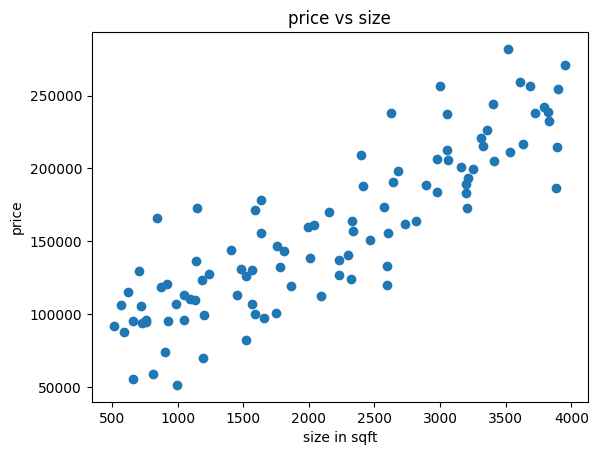

In [133]:
plt.scatter(X,y)
plt.title('price vs size')
plt.xlabel('size in sqft')
plt.ylabel('price')
plt.show()

In [184]:
X_f=np.c_[X, X**2, X**3,X**4, X**5, X**6, X**7, X**8, X**9, X**10, X**11, X**12, X**13]

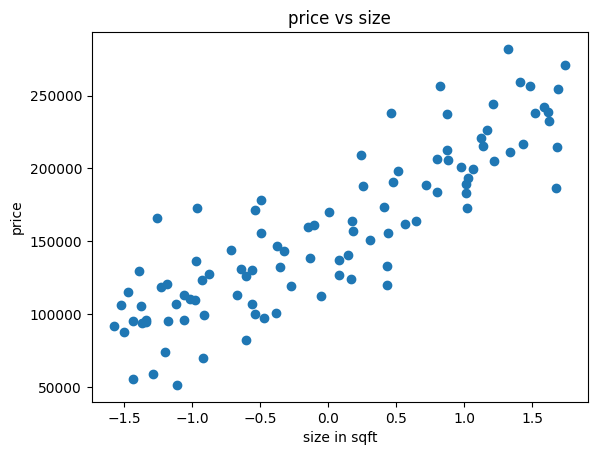

In [185]:
X_fn=normalize(X_f)
X_fn
plt.scatter(X_s,y)
plt.title('price vs size')
plt.xlabel('size in sqft')
plt.ylabel('price')
plt.show()

In [186]:
def compute_cost(X,y,w,b):
    m=X.shape[0]
    cost=0
    for i in range(m):
        fwb_i=X[i]@w+b
        cost=cost+(fwb_i-y[i])**2
    cost=cost/(2*m)

    return cost
        
    

In [187]:
def compute_gradient(X,y,w,b):
   

    m,n=X.shape
    dj_dw=np.zeros(n)
    dj_db=0

    for i in range(m):
        err=(X[i]@w+b)-y[i]
        for j in range(n):
            dj_dw[j]=dj_dw[j]+err*X[i,j]
        dj_db=dj_db+err;

    dj_db=dj_db/m
    dj_dw=dj_dw/m

    
    return dj_db,dj_dw  

    

In [188]:
def gradient_descent(X,y,w_in,b_in,cost_function,gradient_function,aplpha,iterations):

    w=copy.deepcopy(w_in)
    b=b_in
    J_history=[]
    for i in range(iterations):
        dj_db,dj_dw=gradient_function(X,y,w,b)

        w=w-alpha*dj_dw
        b=b-alpha*dj_db

        J_history.append(cost_function(X,y,w,b,))


        if i%math.ceil(iterations/10)==0:
            print(f"Iteration {i:4d} cost:{J_history[-1]:8.2f}")

    return J_history,w,b

In [192]:
w_in=np.zeros(X_fn.shape[1])
b_in=0
alpha=1e-1
iterations=10000
J_history,w,b=gradient_descent(X_fn,y,w_in,b_in,compute_cost,compute_gradient,alpha,iterations)
print(w)

Iteration    0 cost:10649078622.22
Iteration 1000 cost:343280265.88
Iteration 2000 cost:343236161.37
Iteration 3000 cost:343207093.24
Iteration 4000 cost:343186248.32
Iteration 5000 cost:343169962.53
Iteration 6000 cost:343156262.84
Iteration 7000 cost:343144085.20
Iteration 8000 cost:343132854.17
Iteration 9000 cost:343122257.00
[26002.74154406  7145.3536759   5193.77479613  7513.42209418
  8320.3277465   6743.03024864  3705.84255362   330.42247043
 -2559.67307949 -4468.09121407 -5127.18268735 -4399.27521193
 -2209.39432051]


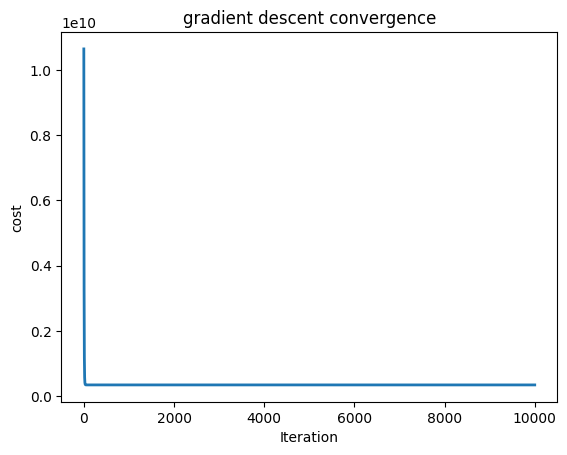

In [190]:
plt.plot(J_history,linewidth=2)
plt.title('gradient descent convergence')
plt.xlabel('Iteration')
plt.ylabel('cost')
plt.show()

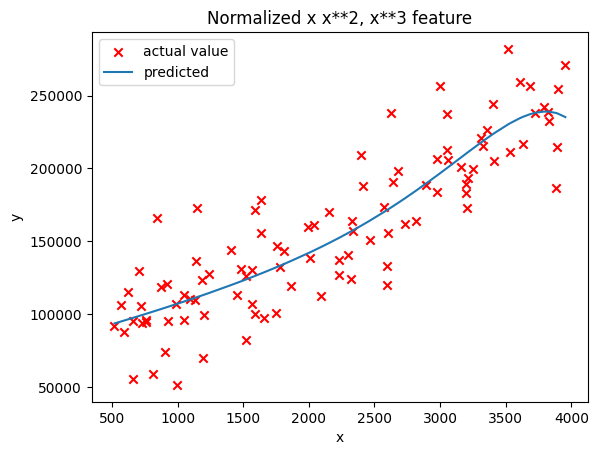

In [191]:
plt.scatter(X,y,marker='x',c='r',label='actual value') 
plt.title("Normalized x x**2, x**3 feature")
plt.plot(X,X_fn@w+b,label='predicted')
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

In [196]:
x = np.arange(0,20,1)
y = np.cos(x/2)

X = np.c_[x, x**2, x**3,x**4, x**5, x**6, x**7, x**8, x**9, x**10, x**11, x**12, x**13]
X_s=normalize(X)

In [211]:
w_in=np.zeros(X_s.shape[1])
b_in=0
alpha=1e-1
iterations=1000000
J_history,w,b=gradient_descent(X_s,y,w_in,b_in,compute_cost,compute_gradient,alpha,iterations)
print(w)

Iteration    0 cost:    0.22
Iteration 100000 cost:    0.02
Iteration 200000 cost:    0.01
Iteration 300000 cost:    0.01
Iteration 400000 cost:    0.01
Iteration 500000 cost:    0.01
Iteration 600000 cost:    0.00
Iteration 700000 cost:    0.00
Iteration 800000 cost:    0.00
Iteration 900000 cost:    0.00
[ -1.33565562 -10.00231728  24.77799625   5.96170981 -12.48587921
 -16.26275994  -9.50807133   0.59194813   8.70295901  11.9412625
   9.27097351   0.78896901 -12.81745188]


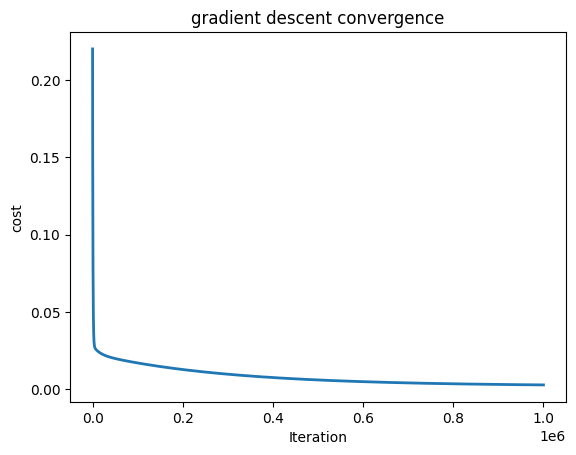

In [212]:
plt.plot(J_history,linewidth=2)
plt.title('gradient descent convergence')
plt.xlabel('Iteration')
plt.ylabel('cost')
plt.show()

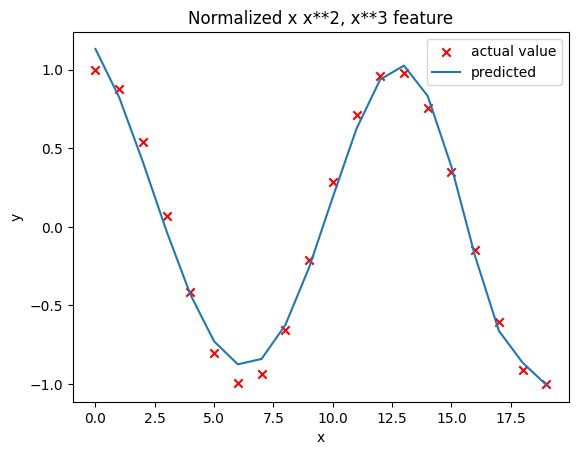

In [213]:
plt.scatter(x,y,marker='x',c='r',label='actual value') 
plt.title("Normalized x x**2, x**3 feature")
plt.plot(x,X_s@w+b,label='predicted')
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()